In [36]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

SEED = 42
BATCH_SIZE = 128
EPOCHS_MLP = 8
EPOCHS_CNN = 5
LR = 1e-3

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [21]:
ROOT_DIR = r"C:\Users\wiad_\PycharmProjects\ItmoCv\data"
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root=ROOT_DIR,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root=ROOT_DIR,
    train=False,
    download=True,
    transform=transform
)

class_names = [str(i) for i in range(10)]

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Classes:", class_names)


Train size: 60000
Test size: 10000
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


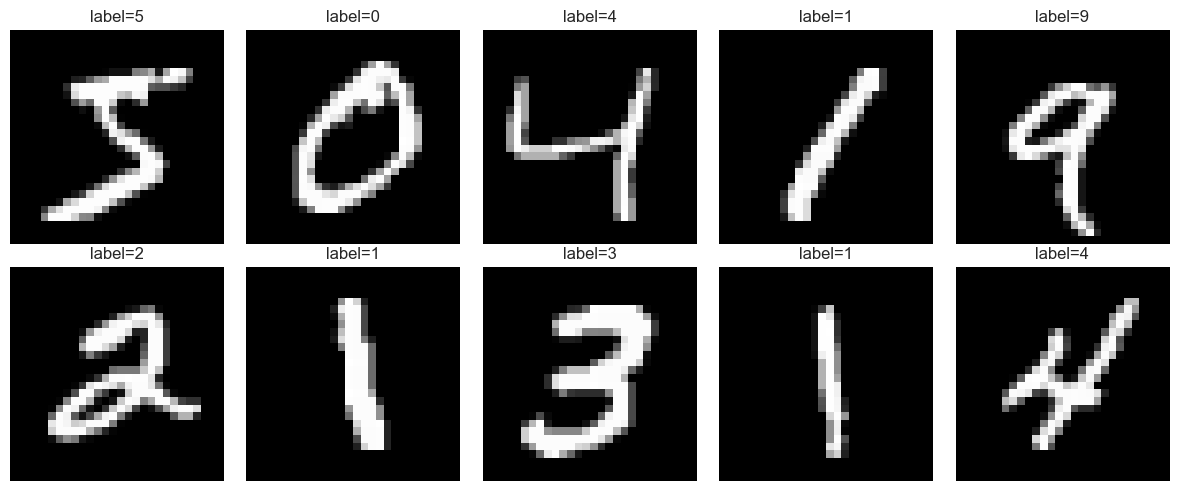

In [22]:

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = train_dataset.data[i].numpy()
    label = train_dataset.targets[i].item()
    ax.imshow(img, cmap="gray")
    ax.set_title(f"label={label}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [23]:
X_full = train_dataset.data.numpy().astype(np.float32) / 255.0
y_full = train_dataset.targets.numpy().astype(np.int64)

X_full_flat = X_full.reshape(-1, 28 * 28)

X_train, X_val, y_train, y_val = train_test_split(
    X_full_flat,
    y_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_full
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)


Train: (48000, 784) (48000,)
Val: (12000, 784) (12000,)


In [24]:
X_train_flat = torch.from_numpy(X_train).float()
X_val_flat = torch.from_numpy(X_val).float()
y_train_t = torch.from_numpy(y_train).long()
y_val_t = torch.from_numpy(y_val).long()

X_train_img = X_train_flat.reshape(-1, 1, 28, 28)
X_val_img = X_val_flat.reshape(-1, 1, 28, 28)

X_test_flat = (test_dataset.data.float() / 255.0).reshape(-1, 28 * 28)
X_test_img = (test_dataset.data.float() / 255.0).unsqueeze(1)
y_test_t = test_dataset.targets.long()

train_flat_ds = TensorDataset(X_train_flat, y_train_t)
val_flat_ds = TensorDataset(X_val_flat, y_val_t)
test_flat_ds = TensorDataset(X_test_flat, y_test_t)

train_img_ds = TensorDataset(X_train_img, y_train_t)
val_img_ds = TensorDataset(X_val_img, y_val_t)
test_img_ds = TensorDataset(X_test_img, y_test_t)

train_flat_loader = DataLoader(train_flat_ds, batch_size=BATCH_SIZE, shuffle=True)
val_flat_loader = DataLoader(val_flat_ds, batch_size=BATCH_SIZE, shuffle=False)
test_flat_loader = DataLoader(test_flat_ds, batch_size=BATCH_SIZE, shuffle=False)

train_img_loader = DataLoader(train_img_ds, batch_size=BATCH_SIZE, shuffle=True)
val_img_loader = DataLoader(val_img_ds, batch_size=BATCH_SIZE, shuffle=False)
test_img_loader = DataLoader(test_img_ds, batch_size=BATCH_SIZE, shuffle=False)


In [25]:
class MLPReLURegularized(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


class MLPReLUNoRegularization(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


class MLPSigmoidRegularized(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.Sigmoid(),
            nn.Dropout(0.30),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.Sigmoid(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.Sigmoid(),
            nn.Dropout(0.20),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.classifier(x)
        return x


In [26]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return acc, f1


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(yb.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc, epoch_f1 = compute_metrics(all_targets, all_preds)
    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        running_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(yb.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc, epoch_f1 = compute_metrics(all_targets, all_preds)
    return epoch_loss, epoch_acc, epoch_f1


def fit_model(model, train_loader, val_loader, epochs=15, lr=1e-3, weight_decay=0.0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": []
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} | "
            f"train_f1={train_f1:.4f} val_f1={val_f1:.4f}"
        )

    return model, history


@torch.no_grad()
def evaluate_on_test(model, loader):
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, test_f1 = evaluate(model, loader, criterion)
    return {
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1
    }


In [27]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return acc, f1


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(yb.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc, epoch_f1 = compute_metrics(all_targets, all_preds)
    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        running_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(yb.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc, epoch_f1 = compute_metrics(all_targets, all_preds)
    return epoch_loss, epoch_acc, epoch_f1


def fit_model(model, train_loader, val_loader, epochs=15, lr=1e-3, weight_decay=0.0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": []
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} | "
            f"train_f1={train_f1:.4f} val_f1={val_f1:.4f}"
        )

    return model, history


@torch.no_grad()
def evaluate_on_test(model, loader):
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, test_f1 = evaluate(model, loader, criterion)
    return {
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1
    }


In [28]:
def plot_history(history, title):
    epochs = history["epoch"]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(epochs, history["train_loss"], marker="o", label="train loss")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="val loss")
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], marker="o", label="train acc")
    axes[1].plot(epochs, history["val_acc"], marker="o", label="val acc")
    axes[1].plot(epochs, history["train_f1"], marker="s", linestyle="--", label="train f1")
    axes[1].plot(epochs, history["val_f1"], marker="s", linestyle="--", label="val f1")
    axes[1].set_title(f"{title}: Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def compare_histories(histories, metric_key, title, ylabel):
    plt.figure(figsize=(9, 5))
    for name, hist in histories.items():
        plt.plot(hist["epoch"], hist[metric_key], marker="o", label=name)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()


Epoch 01/8 | train_loss=0.3161 val_loss=0.1183 | train_acc=0.9156 val_acc=0.9654 | train_f1=0.9146 val_f1=0.9652
Epoch 02/8 | train_loss=0.1425 val_loss=0.0902 | train_acc=0.9579 val_acc=0.9723 | train_f1=0.9576 val_f1=0.9722
Epoch 03/8 | train_loss=0.1061 val_loss=0.0845 | train_acc=0.9668 val_acc=0.9738 | train_f1=0.9666 val_f1=0.9736
Epoch 04/8 | train_loss=0.0898 val_loss=0.0826 | train_acc=0.9721 val_acc=0.9752 | train_f1=0.9718 val_f1=0.9751
Epoch 05/8 | train_loss=0.0796 val_loss=0.0696 | train_acc=0.9751 val_acc=0.9793 | train_f1=0.9749 val_f1=0.9792
Epoch 06/8 | train_loss=0.0702 val_loss=0.0743 | train_acc=0.9774 val_acc=0.9784 | train_f1=0.9772 val_f1=0.9783
Epoch 07/8 | train_loss=0.0639 val_loss=0.0694 | train_acc=0.9795 val_acc=0.9792 | train_f1=0.9794 val_f1=0.9791
Epoch 08/8 | train_loss=0.0563 val_loss=0.0718 | train_acc=0.9818 val_acc=0.9798 | train_f1=0.9816 val_f1=0.9796


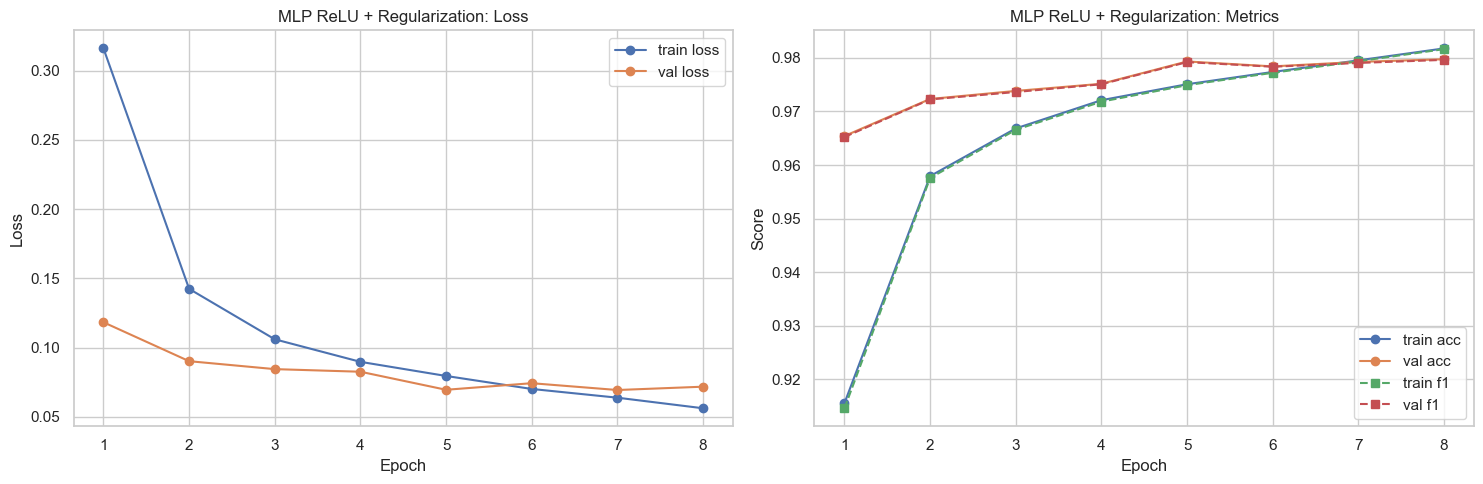

In [29]:
mlp_reg = MLPReLURegularized()
mlp_reg, hist_reg = fit_model(
    model=mlp_reg,
    train_loader=train_flat_loader,
    val_loader=val_flat_loader,
    epochs=EPOCHS_MLP,
    lr=LR,
    weight_decay=1e-4
)

plot_history(hist_reg, "MLP ReLU + Regularization")


Epoch 01/8 | train_loss=0.3484 val_loss=0.1488 | train_acc=0.8955 val_acc=0.9566 | train_f1=0.8943 val_f1=0.9561
Epoch 02/8 | train_loss=0.1175 val_loss=0.1188 | train_acc=0.9643 val_acc=0.9641 | train_f1=0.9640 val_f1=0.9638
Epoch 03/8 | train_loss=0.0744 val_loss=0.1035 | train_acc=0.9764 val_acc=0.9704 | train_f1=0.9763 val_f1=0.9703
Epoch 04/8 | train_loss=0.0545 val_loss=0.0932 | train_acc=0.9826 val_acc=0.9724 | train_f1=0.9825 val_f1=0.9723
Epoch 05/8 | train_loss=0.0384 val_loss=0.0805 | train_acc=0.9872 val_acc=0.9780 | train_f1=0.9871 val_f1=0.9779
Epoch 06/8 | train_loss=0.0301 val_loss=0.1023 | train_acc=0.9901 val_acc=0.9715 | train_f1=0.9901 val_f1=0.9714
Epoch 07/8 | train_loss=0.0242 val_loss=0.1231 | train_acc=0.9924 val_acc=0.9699 | train_f1=0.9924 val_f1=0.9696
Epoch 08/8 | train_loss=0.0219 val_loss=0.0833 | train_acc=0.9926 val_acc=0.9791 | train_f1=0.9925 val_f1=0.9790


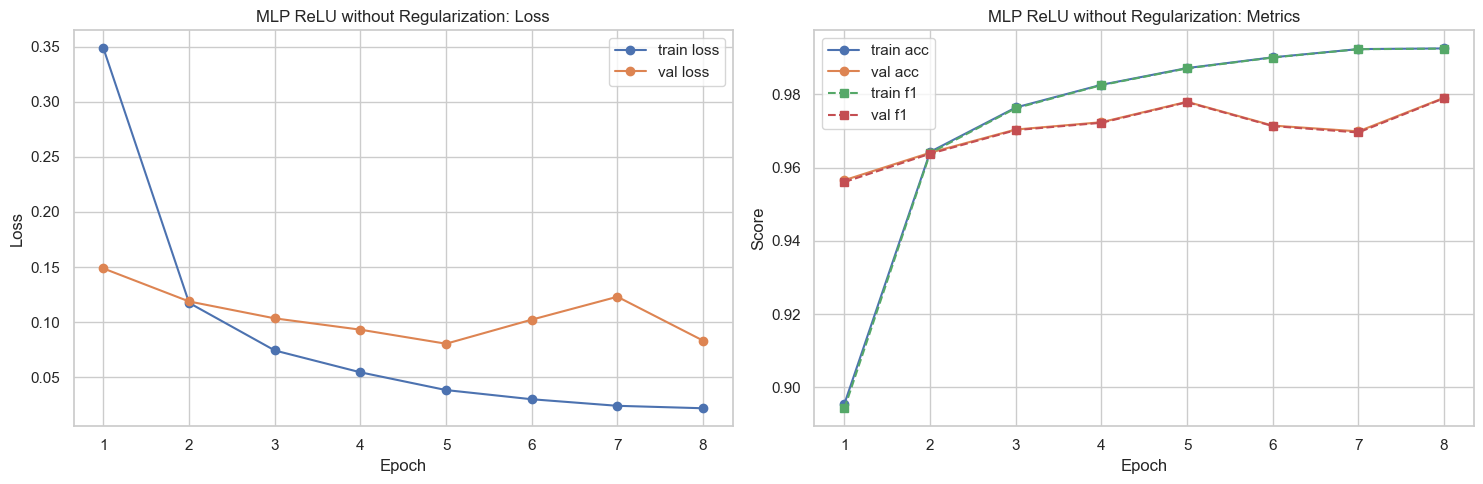

In [30]:
mlp_noreg = MLPReLUNoRegularization()
mlp_noreg, hist_noreg = fit_model(
    model=mlp_noreg,
    train_loader=train_flat_loader,
    val_loader=val_flat_loader,
    epochs=EPOCHS_MLP,
    lr=LR,
    weight_decay=0.0
)

plot_history(hist_noreg, "MLP ReLU without Regularization")


Epoch 01/8 | train_loss=0.8592 val_loss=0.3821 | train_acc=0.8167 val_acc=0.9038 | train_f1=0.8121 val_f1=0.9027
Epoch 02/8 | train_loss=0.4346 val_loss=0.2947 | train_acc=0.8780 val_acc=0.9142 | train_f1=0.8763 val_f1=0.9130
Epoch 03/8 | train_loss=0.3702 val_loss=0.2532 | train_acc=0.8926 val_acc=0.9263 | train_f1=0.8912 val_f1=0.9258
Epoch 04/8 | train_loss=0.3322 val_loss=0.2231 | train_acc=0.9006 val_acc=0.9337 | train_f1=0.8993 val_f1=0.9330
Epoch 05/8 | train_loss=0.3056 val_loss=0.2167 | train_acc=0.9078 val_acc=0.9347 | train_f1=0.9067 val_f1=0.9340
Epoch 06/8 | train_loss=0.2832 val_loss=0.1906 | train_acc=0.9135 val_acc=0.9417 | train_f1=0.9124 val_f1=0.9410
Epoch 07/8 | train_loss=0.2606 val_loss=0.1734 | train_acc=0.9220 val_acc=0.9473 | train_f1=0.9212 val_f1=0.9470
Epoch 08/8 | train_loss=0.2452 val_loss=0.1713 | train_acc=0.9255 val_acc=0.9488 | train_f1=0.9247 val_f1=0.9483


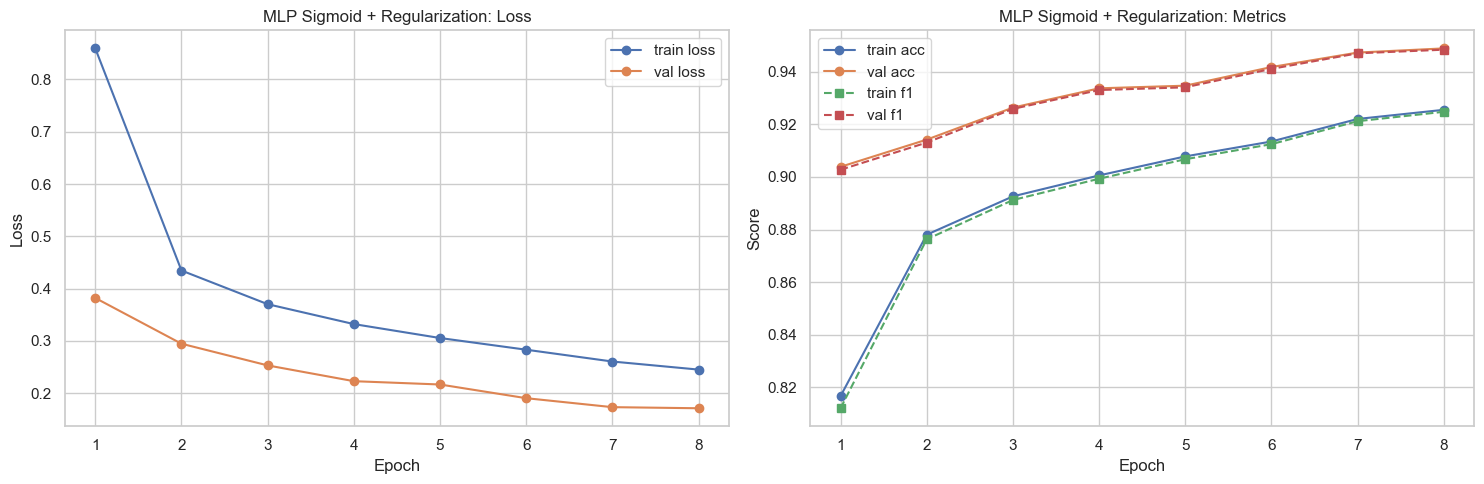

In [31]:
mlp_sigmoid = MLPSigmoidRegularized()
mlp_sigmoid, hist_sigmoid = fit_model(
    model=mlp_sigmoid,
    train_loader=train_flat_loader,
    val_loader=val_flat_loader,
    epochs=EPOCHS_MLP,
    lr=LR,
    weight_decay=1e-4
)

plot_history(hist_sigmoid, "MLP Sigmoid + Regularization")


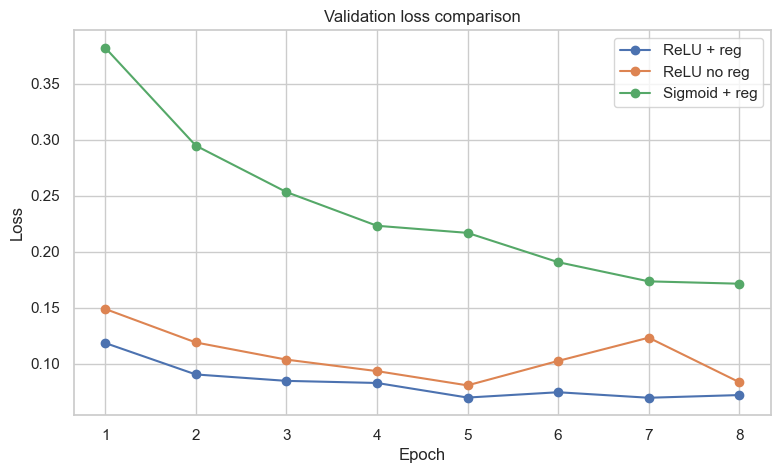

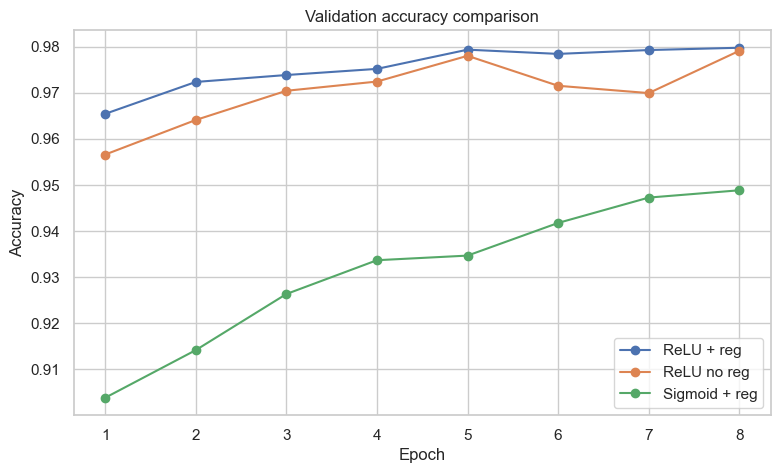

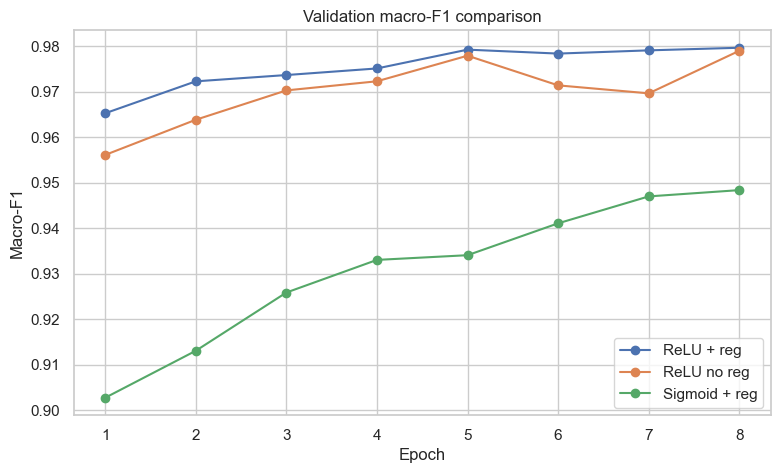

In [32]:
histories_mlp = {
    "ReLU + reg": hist_reg,
    "ReLU no reg": hist_noreg,
    "Sigmoid + reg": hist_sigmoid
}

compare_histories(histories_mlp, "val_loss", "Validation loss comparison", "Loss")
compare_histories(histories_mlp, "val_acc", "Validation accuracy comparison", "Accuracy")
compare_histories(histories_mlp, "val_f1", "Validation macro-F1 comparison", "Macro-F1")


In [33]:
results_mlp = pd.DataFrame([
    {
        "model": "MLP ReLU + reg",
        "best_val_acc": max(hist_reg["val_acc"]),
        "best_val_f1": max(hist_reg["val_f1"]),
        "best_epoch_acc": hist_reg["epoch"][int(np.argmax(hist_reg["val_acc"]))],
        "min_val_loss": min(hist_reg["val_loss"])
    },
    {
        "model": "MLP ReLU no reg",
        "best_val_acc": max(hist_noreg["val_acc"]),
        "best_val_f1": max(hist_noreg["val_f1"]),
        "best_epoch_acc": hist_noreg["epoch"][int(np.argmax(hist_noreg["val_acc"]))],
        "min_val_loss": min(hist_noreg["val_loss"])
    },
    {
        "model": "MLP Sigmoid + reg",
        "best_val_acc": max(hist_sigmoid["val_acc"]),
        "best_val_f1": max(hist_sigmoid["val_f1"]),
        "best_epoch_acc": hist_sigmoid["epoch"][int(np.argmax(hist_sigmoid["val_acc"]))],
        "min_val_loss": min(hist_sigmoid["val_loss"])
    }
])

results_mlp.sort_values("best_val_acc", ascending=False)


,model,best_val_acc,best_val_f1,best_epoch_acc,min_val_loss
0,MLP ReLU + reg,0.979750,0.979629,8,0.069429
1,MLP ReLU no reg,0.979083,0.978961,8,0.080491
2,MLP Sigmoid + reg,0.948833,0.948346,8,0.171314


In [34]:
test_metrics_mlp = pd.DataFrame([
    {"model": "MLP ReLU + reg", **evaluate_on_test(mlp_reg, test_flat_loader)},
    {"model": "MLP ReLU no reg", **evaluate_on_test(mlp_noreg, test_flat_loader)},
    {"model": "MLP Sigmoid + reg", **evaluate_on_test(mlp_sigmoid, test_flat_loader)}
])

test_metrics_mlp.sort_values("test_acc", ascending=False)


,model,test_loss,test_acc,test_f1
1,MLP ReLU no reg,0.076650,0.9798,0.979679
0,MLP ReLU + reg,0.063412,0.9797,0.979618
2,MLP Sigmoid + reg,0.166281,0.9511,0.950385


Epoch 01/5 | train_loss=0.4135 val_loss=0.1170 | train_acc=0.8697 val_acc=0.9666 | train_f1=0.8686 val_f1=0.9665
Epoch 02/5 | train_loss=0.1239 val_loss=0.0846 | train_acc=0.9621 val_acc=0.9764 | train_f1=0.9619 val_f1=0.9764
Epoch 03/5 | train_loss=0.0893 val_loss=0.0665 | train_acc=0.9721 val_acc=0.9796 | train_f1=0.9719 val_f1=0.9794
Epoch 04/5 | train_loss=0.0714 val_loss=0.0551 | train_acc=0.9774 val_acc=0.9831 | train_f1=0.9772 val_f1=0.9830
Epoch 05/5 | train_loss=0.0585 val_loss=0.0495 | train_acc=0.9819 val_acc=0.9842 | train_f1=0.9817 val_f1=0.9840


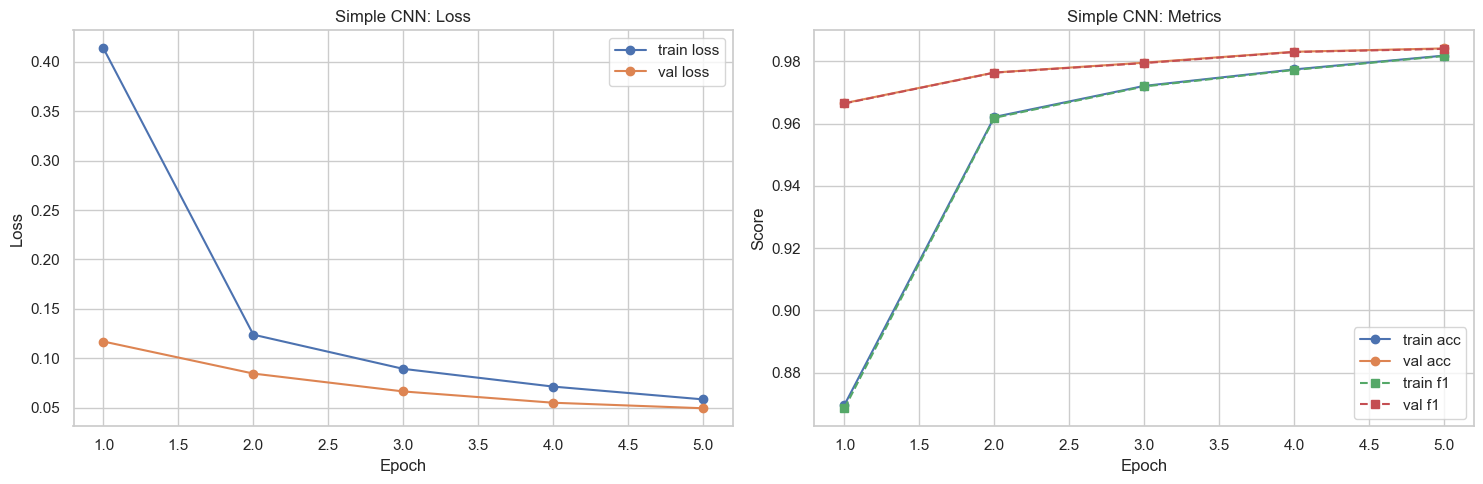

In [38]:
cnn = SimpleCNN()
cnn, hist_cnn = fit_model(
    model=cnn,
    train_loader=train_img_loader,
    val_loader=val_img_loader,
    epochs=EPOCHS_CNN,
    lr=LR,
    weight_decay=1e-4
)

plot_history(hist_cnn, "Simple CNN")


In [39]:
test_metrics_cnn = pd.DataFrame([
    {"model": "Simple CNN", **evaluate_on_test(cnn, test_img_loader)}
])

test_metrics_cnn


,model,test_loss,test_acc,test_f1
0,Simple CNN,0.04023,0.9863,0.986233


In [40]:
def get_activations(model, x):
    activations = {}

    def hook_fn(name):
        def hook(module, inputs, output):
            activations[name] = output.detach().cpu()
        return hook

    h1 = model.conv1.register_forward_hook(hook_fn("conv1"))
    h2 = model.conv2.register_forward_hook(hook_fn("conv2"))

    model.eval()
    with torch.no_grad():
        _ = model(x.to(device))

    h1.remove()
    h2.remove()

    return activations


sample_idx = 0
sample_img, sample_label = val_img_ds[sample_idx]
sample_batch = sample_img.unsqueeze(0)

acts = get_activations(cnn, sample_batch)

print("True label:", sample_label.item())
print("conv1 shape:", acts["conv1"].shape)
print("conv2 shape:", acts["conv2"].shape)


True label: 7
conv1 shape: torch.Size([1, 16, 28, 28])
conv2 shape: torch.Size([1, 32, 14, 14])


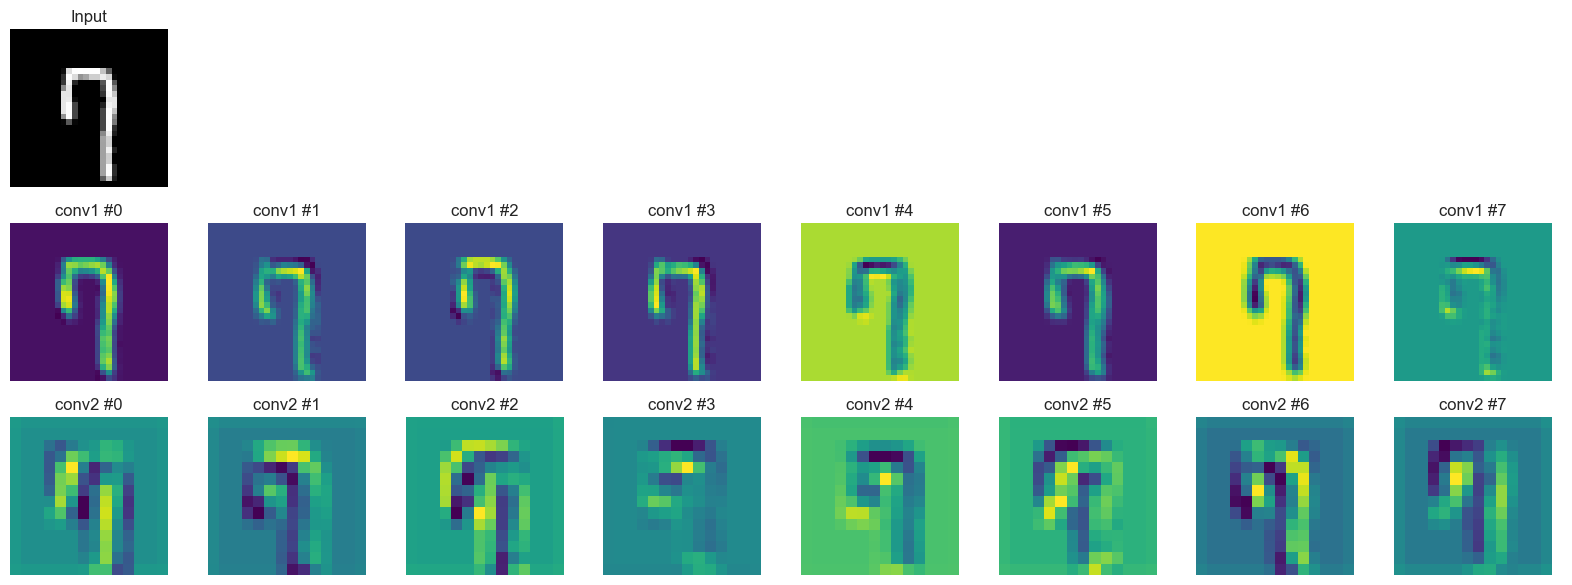

In [41]:
def show_feature_maps(input_img, activations, max_maps=8):
    fig, axes = plt.subplots(3, max_maps, figsize=(2 * max_maps, 6))

    for j in range(max_maps):
        axes[0, j].axis("off")
    axes[0, 0].imshow(input_img.squeeze(), cmap="gray")
    axes[0, 0].set_title("Input")
    axes[0, 0].axis("off")

    conv1_maps = activations["conv1"][0]
    conv2_maps = activations["conv2"][0]

    for j in range(max_maps):
        if j < conv1_maps.shape[0]:
            axes[1, j].imshow(conv1_maps[j], cmap="viridis")
            axes[1, j].set_title(f"conv1 #{j}")
        axes[1, j].axis("off")

    for j in range(max_maps):
        if j < conv2_maps.shape[0]:
            axes[2, j].imshow(conv2_maps[j], cmap="viridis")
            axes[2, j].set_title(f"conv2 #{j}")
        axes[2, j].axis("off")

    plt.tight_layout()
    plt.show()


show_feature_maps(sample_img.numpy(), acts, max_maps=8)


Label: 7


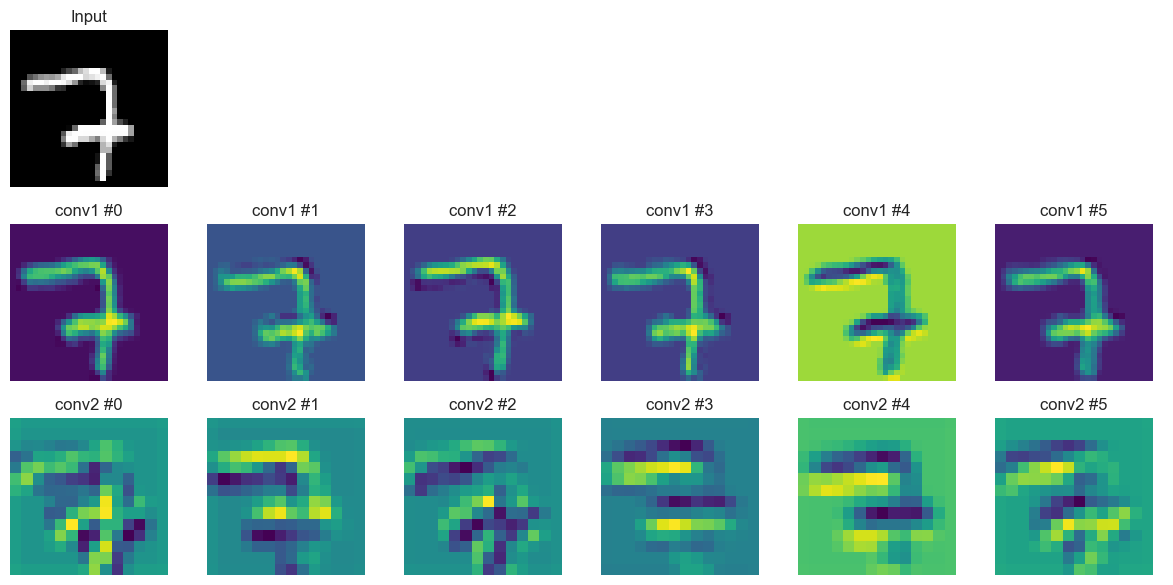

Label: 6


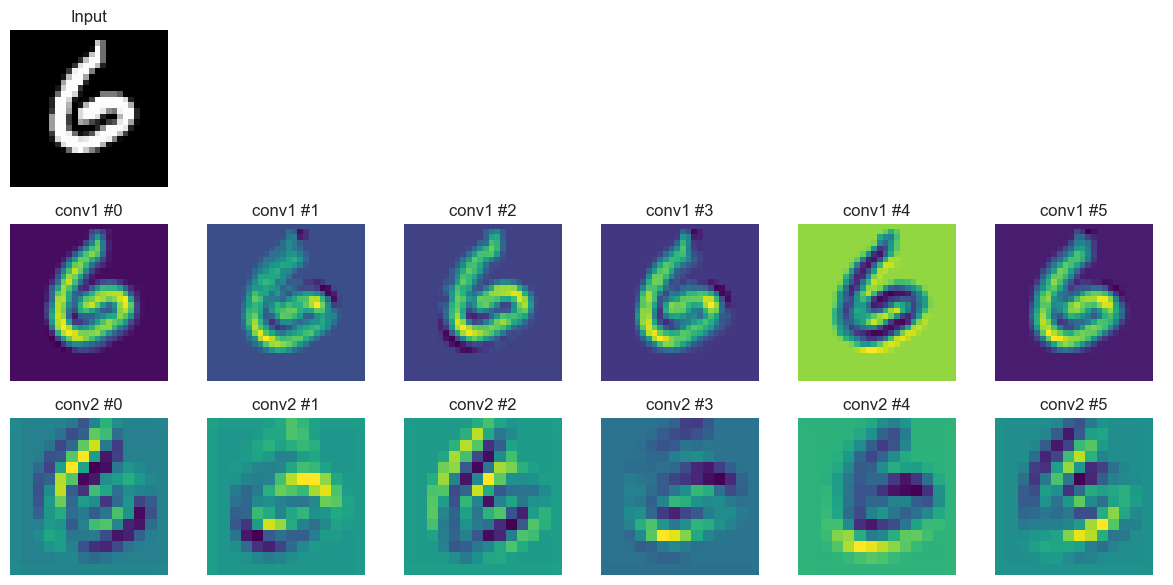

Label: 4


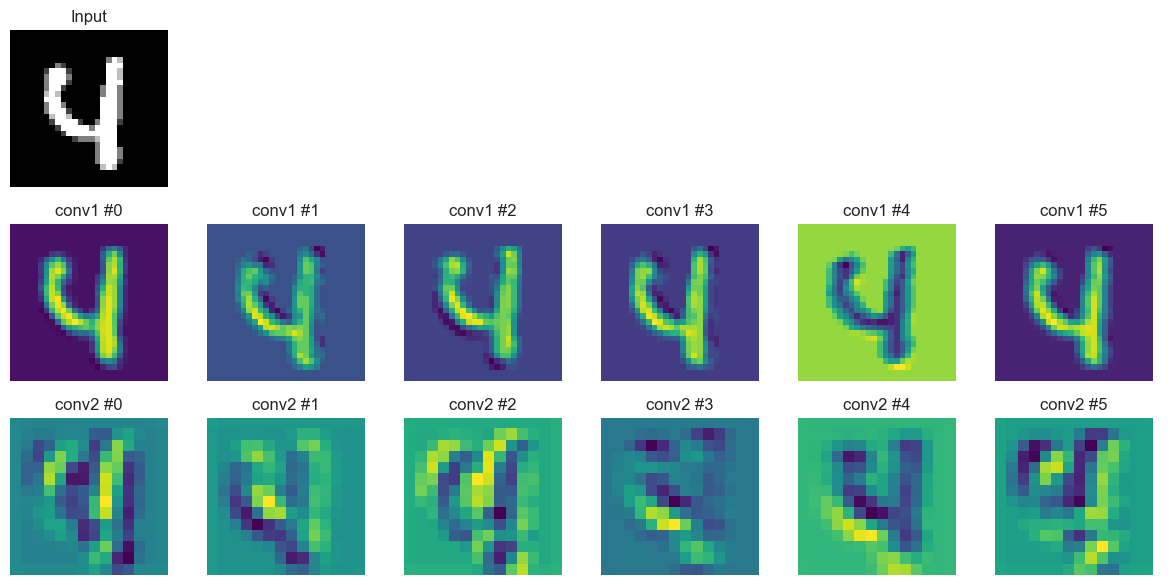

In [42]:
for sample_idx in [1, 7, 15]:
    sample_img, sample_label = val_img_ds[sample_idx]
    sample_batch = sample_img.unsqueeze(0)
    acts = get_activations(cnn, sample_batch)

    print(f"Label: {sample_label.item()}")
    show_feature_maps(sample_img.numpy(), acts, max_maps=6)


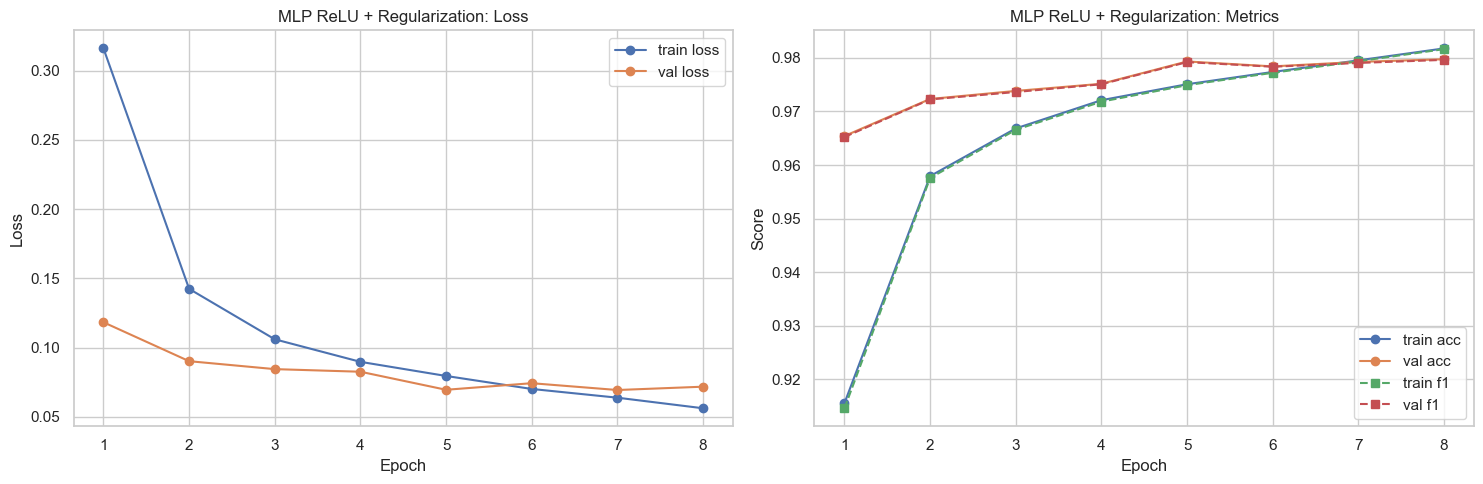

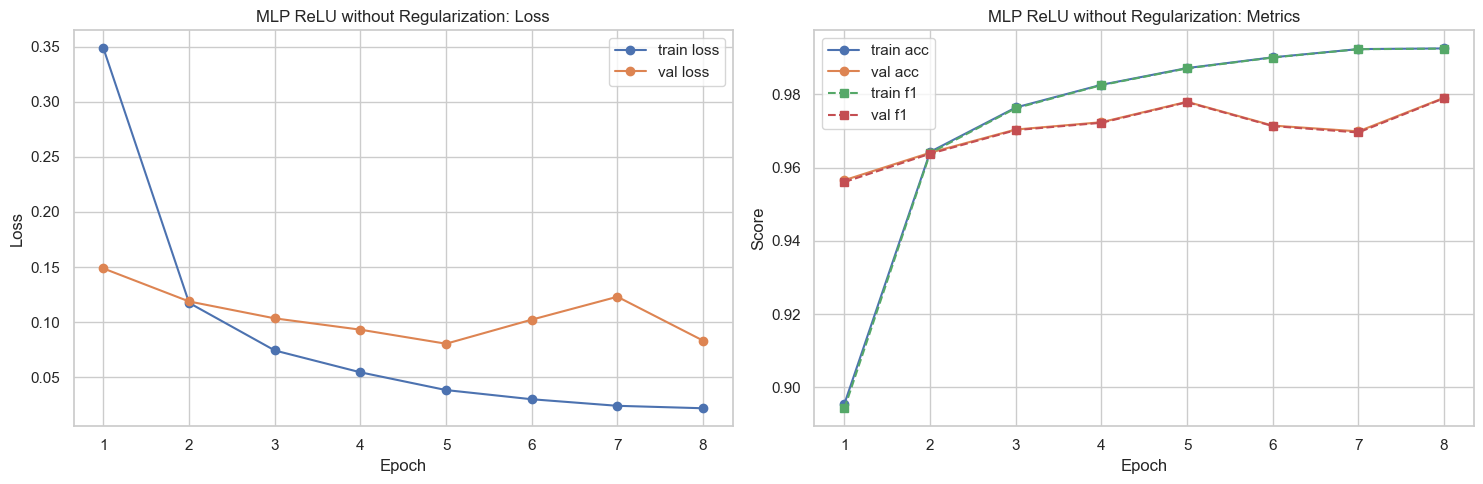

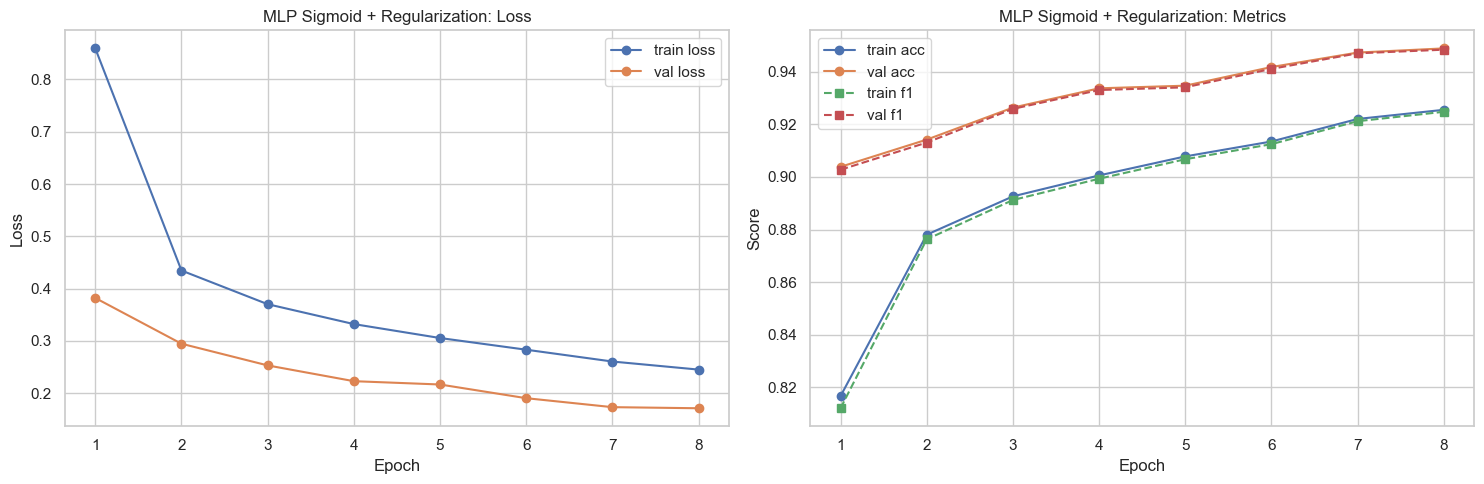

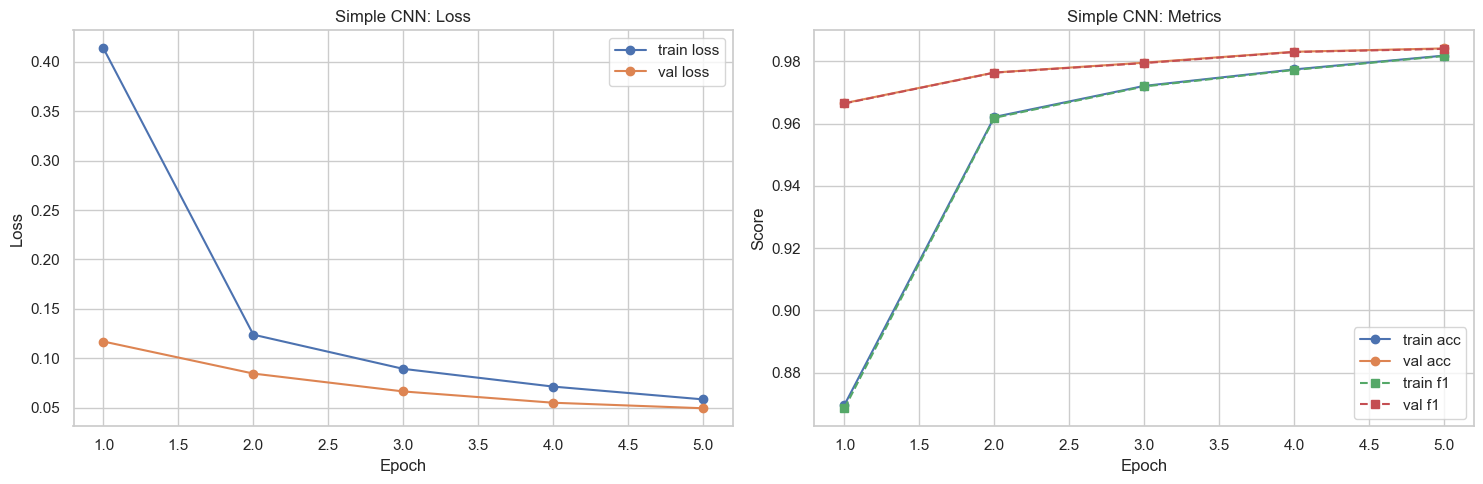

In [43]:
os.makedirs("figures", exist_ok=True)

def save_history_plot(history, title, filename):
    epochs = history["epoch"]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(epochs, history["train_loss"], marker="o", label="train loss")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="val loss")
    axes[0].set_title(f"{title}: Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], marker="o", label="train acc")
    axes[1].plot(epochs, history["val_acc"], marker="o", label="val acc")
    axes[1].plot(epochs, history["train_f1"], marker="s", linestyle="--", label="train f1")
    axes[1].plot(epochs, history["val_f1"], marker="s", linestyle="--", label="val f1")
    axes[1].set_title(f"{title}: Metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

save_history_plot(hist_reg, "MLP ReLU + Regularization", "figures/mlp_reg.png")
save_history_plot(hist_noreg, "MLP ReLU without Regularization", "figures/mlp_noreg.png")
save_history_plot(hist_sigmoid, "MLP Sigmoid + Regularization", "figures/mlp_sigmoid.png")
save_history_plot(hist_cnn, "Simple CNN", "figures/cnn.png")

results_mlp.to_csv("figures/results_mlp.csv", index=False)
test_metrics_mlp.to_csv("figures/test_metrics_mlp.csv", index=False)
test_metrics_cnn.to_csv("figures/test_metrics_cnn.csv", index=False)
